# Relatório Técnico: Redes Neurais para Classificação Estelar (SDSS17)

## Processo Trainee CIS - IEEE UnB | Período 2

### 1. Introdução e Análise Exploratória (EDA)

O objetivo deste projeto é construir uma Rede Neural Artificial (RNA) em PyTorch capaz de classificar corpos celestes em três categorias: Galáxias, Estrelas e Quasares (QSO).

O primeiro passo é importar os dados do SDSS17, verificar o balanceamento das classes e procurar por anomalias físicas nos dados captados pelos telescópios.

Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes

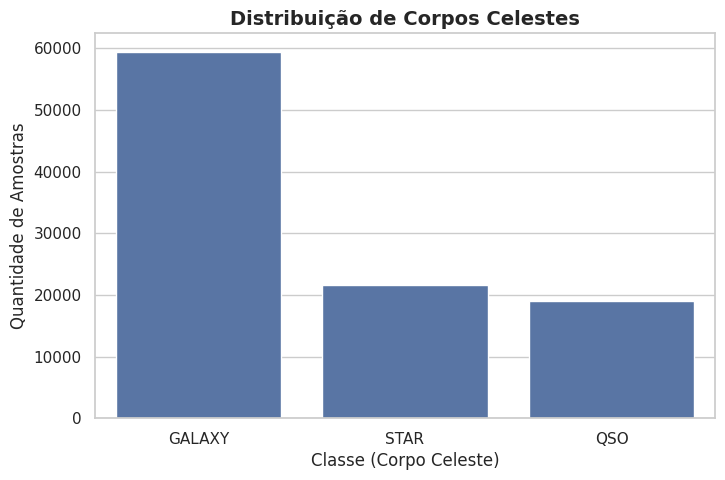

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregamento dos Dados
path = "/content/sample_data/star_classification.csv"
df = pd.read_csv(path)

print("Informações do Dataset:")
df.info()
print("\nValores Nulos:", df.isnull().sum().sum())

# 2. Análise de Balanceamento
sns.set_theme(style="whitegrid")
proporcoes = df['class'].value_counts(normalize=True) * 100
print("\nDistribuição das classes (%):\n", proporcoes)

# 3. Visualização
plt.figure(figsize=(8,5))
grafico_classes = sns.countplot(data=df, x='class', order=df['class'].value_counts().index)
plt.title('Distribuição de Corpos Celestes', fontsize=14, fontweight='bold')
plt.xlabel('Classe (Corpo Celeste)', fontsize=12)
plt.ylabel('Quantidade de Amostras', fontsize=12)
plt.show()

### 2. Limpeza, Pré-processamento e Logística de Tensores

Redes Neurais são sensíveis à escala dos dados. Nesta etapa:

1. Removidos metadados do telescópio que não agregam valor físico.

2. Removidas linhas com falha de leitura (códigos -9999).

3. Padronização da escala com StandardScaler para estabilizar o Gradiente Descendente.
  
4. Convertidos dados para Tensores e criação dos DataLoaders (batches de 64).

In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader

# Remoção de colunas inúteis
colunas_remover = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col','field_ID','spec_obj_ID', 'fiber_ID', 'MJD']
df_limpo = df.drop(columns=colunas_remover)

# Remoção de anomalias (erro de leitura do telescópio)
df_limpo = df_limpo[
    (df_limpo['u'] > -100) &
    (df_limpo['g'] > -100) &
    (df_limpo['z'] > -100)
]

# Separação e Encoding
X = df_limpo[['u','g','r','i','z','redshift']]
y = df_limpo['class']

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Padronização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Criação de Tensores e DataLoaders
train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
test_dataset = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Logística de dados concluída com sucesso! DataLoaders criados.")

Logística de dados concluída com sucesso! DataLoaders criados.


### 3. O Modelo de Referência (Baseline) e Diagnóstico de Treinamento

Para estabelecer um ponto de referência, foi criada primeiro uma rede relativamente "estreita e rasa":

**Topologia:** 6 features -> 32 neurônios -> 16 neurônios -> 3 classes.
Esta rede tem menos parâmetros, o que torna o treino rápido, mas limita a sua capacidade de aprender padrões astrofísicos extremamente complexos.

Treinamento da rede com uma Taxa de Aprendizado (Learning Rate) de 0.001, para o Otimizador Adam, permitindo passos consistentes sem "pular" o mínimo global.

Foram usadas 30 Épocas, salvando o histórico de erros para gerar a Curva de Aprendizado e diagnosticar a saúde do modelo.

**Underfitting:** Ocorreria se o modelo travasse em um erro alto no Treino.

**Overfitting:** Ocorreria se a linha de Erro de Treino caísse perto de zero, mas o Erro de Teste começasse a subir desenfreadamente.

In [4]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class StarClassifierBase(nn.Module):
    def __init__(self):
        super(StarClassifierBase, self).__init__()
        self.fc1 = nn.Linear(in_features=6, out_features=32)
        self.fc2 = nn.Linear(in_features=32, out_features=16)
        self.fc3 = nn.Linear(in_features=16, out_features=3)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

modelo_base = StarClassifierBase()

# Termômetro de Erro e Motor de Ajuste
criterion = nn.CrossEntropyLoss()
optimizer_base = optim.Adam(modelo_base.parameters(), lr=0.001)

EPOCHS = 30
train_losses_base, test_losses_base = [], []

print("Iniciando Treinamento da Rede Base...")
for epoch in range(EPOCHS):
    # TREINO
    modelo_base.train()
    running_train_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer_base.zero_grad()
        loss = criterion(modelo_base(batch_X), batch_y)
        loss.backward()
        optimizer_base.step()
        running_train_loss += loss.item()
    train_losses_base.append(running_train_loss / len(train_loader))

    # AVALIAÇÃO
    modelo_base.eval()
    running_test_loss = 0.0
    acertos, total = 0, 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            previsoes = modelo_base(batch_X)
            loss = criterion(previsoes, batch_y)
            running_test_loss += loss.item()

            _, classe_prevista = torch.max(previsoes, 1)
            total += batch_y.size(0)
            acertos += (classe_prevista == batch_y).sum().item()

    test_losses_base.append(running_test_loss / len(test_loader))

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Época [{epoch+1:02d}/{EPOCHS}] | Loss Treino: {train_losses_base[-1]:.4f} | Loss Teste: {test_losses_base[-1]:.4f} | Acurácia: {(acertos/total)*100:.2f}%")

Iniciando Treinamento da Rede Base...
Época [01/30] | Loss Treino: 0.3040 | Loss Teste: 0.1613 | Acurácia: 95.55%
Época [10/30] | Loss Treino: 0.1050 | Loss Teste: 0.1195 | Acurácia: 96.31%
Época [20/30] | Loss Treino: 0.0977 | Loss Teste: 0.0995 | Acurácia: 97.05%
Época [30/30] | Loss Treino: 0.0939 | Loss Teste: 0.0947 | Acurácia: 97.22%


### 4. Curva de Aprendizado (Diagnóstico Visual)

Plot da Curva de Aprendizado para garantir que a escolha de Épocas (30) e Learning Rate (0.001) foi adequada. Como as duas linhas caem juntas, foi atingido um estado de Good Fit. A rede aprendeu sem sofrer de Underfitting nem Overfitting abrupto.

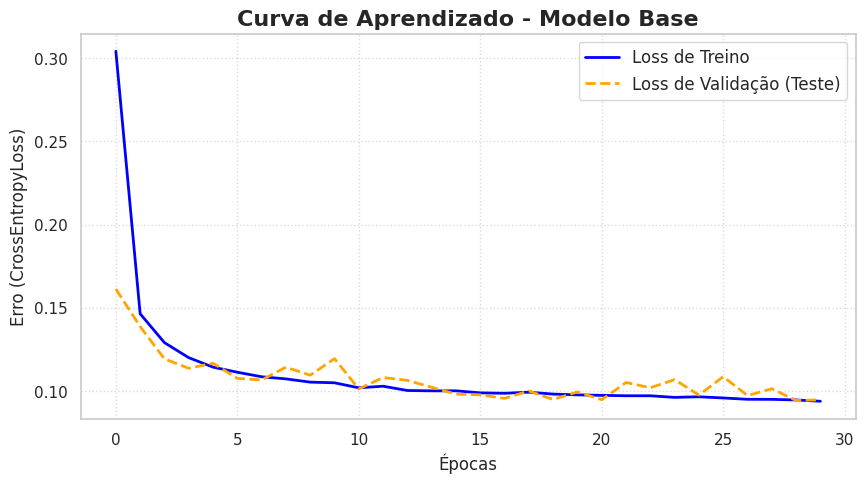

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses_base, label='Loss de Treino', color='blue', linewidth=2)
plt.plot(test_losses_base, label='Loss de Validação (Teste)', color='orange', linewidth=2, linestyle='--')
plt.title('Curva de Aprendizado - Modelo Base', fontsize=16, fontweight='bold')
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Erro (CrossEntropyLoss)', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

### 5. Testando a Topologia, Regularização e Otimização Avançada

Para desafiar a rede, foi construída a StarClassifierAdvanced. Ela é mais Larga (128 neurônios na primeira camada) e mais Profunda (3 camadas ocultas: 128 -> 64 -> 32). Isso dá à rede um enorme poder de memorização.

Sabendo que redes profundas tendem ao Overfitting, foram aplicadas técnicas de mitigação:

**Regularização (Dropout de 30%):** A função nn.Dropout(p=0.3) desliga aleatoriamente 30% dos neurônios a cada iteração de treino. Isso força a rede a não depender de "caminhos fáceis" e aprender a física real.

**Otimização (Adam):** Foi mantido o otimizador Adam, que adapta a taxa de aprendizado por parâmetro, sendo muito superior ao SGD clássico.

In [6]:
class StarClassifierAdvanced(nn.Module):
    def __init__(self):
        super(StarClassifierAdvanced, self).__init__()
        # Topologia mais Larga e Profunda
        self.fc1 = nn.Linear(in_features=6, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=64)
        self.fc3 = nn.Linear(in_features=64, out_features=32)
        self.fc4 = nn.Linear(in_features=32, out_features=3)

        # REGULARIZAÇÃO: Dropout para evitar Overfitting na rede profunda
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x) # Aplicação da Regularização
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.fc4(x)
        return x

modelo_avancado = StarClassifierAdvanced()
optimizer_avancado = optim.Adam(modelo_avancado.parameters(), lr=0.001)

train_losses_adv, test_losses_adv = [], []

print("Treinando a Rede Avançada (Mais larga, Mais profunda + Dropout)...")
for epoch in range(EPOCHS):
    # TREINO (Ativa Dropout)
    modelo_avancado.train()
    running_train_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer_avancado.zero_grad()
        loss = criterion(modelo_avancado(batch_X), batch_y)
        loss.backward()
        optimizer_avancado.step()
        running_train_loss += loss.item()
    train_losses_adv.append(running_train_loss / len(train_loader))

    # AVALIAÇÃO (Desativa Dropout)
    modelo_avancado.eval()
    running_test_loss = 0.0
    acertos, total = 0, 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            previsoes = modelo_avancado(batch_X)
            loss = criterion(previsoes, batch_y)
            running_test_loss += loss.item()

            _, classe_prevista = torch.max(previsoes, 1)
            total += batch_y.size(0)
            acertos += (classe_prevista == batch_y).sum().item()

    test_losses_adv.append(running_test_loss / len(test_loader))

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Época [{epoch+1:02d}/{EPOCHS}] | Loss Treino: {train_losses_adv[-1]:.4f} | Loss Teste: {test_losses_adv[-1]:.4f} | Acurácia: {(acertos/total)*100:.2f}%")

Treinando a Rede Avançada (Mais larga, Mais profunda + Dropout)...
Época [01/30] | Loss Treino: 0.2478 | Loss Teste: 0.1282 | Acurácia: 96.19%
Época [10/30] | Loss Treino: 0.1188 | Loss Teste: 0.0975 | Acurácia: 97.15%
Época [20/30] | Loss Treino: 0.1127 | Loss Teste: 0.0973 | Acurácia: 97.08%
Época [30/30] | Loss Treino: 0.1087 | Loss Teste: 0.1032 | Acurácia: 96.81%


### 6. Comparação Final: Matrizes de Confusão

Ao extrair as previsões de ambos os modelos, podemos avaliar o efeito direto das nossas mudanças de Topologia e Regularização.

O modelo avançado tende a ser muito mais robusto, generalizando melhor em dados invisíveis do que o modelo raso, lidando muito bem com a ambiguidade física existente entre Galáxias e Quasares (QSO).

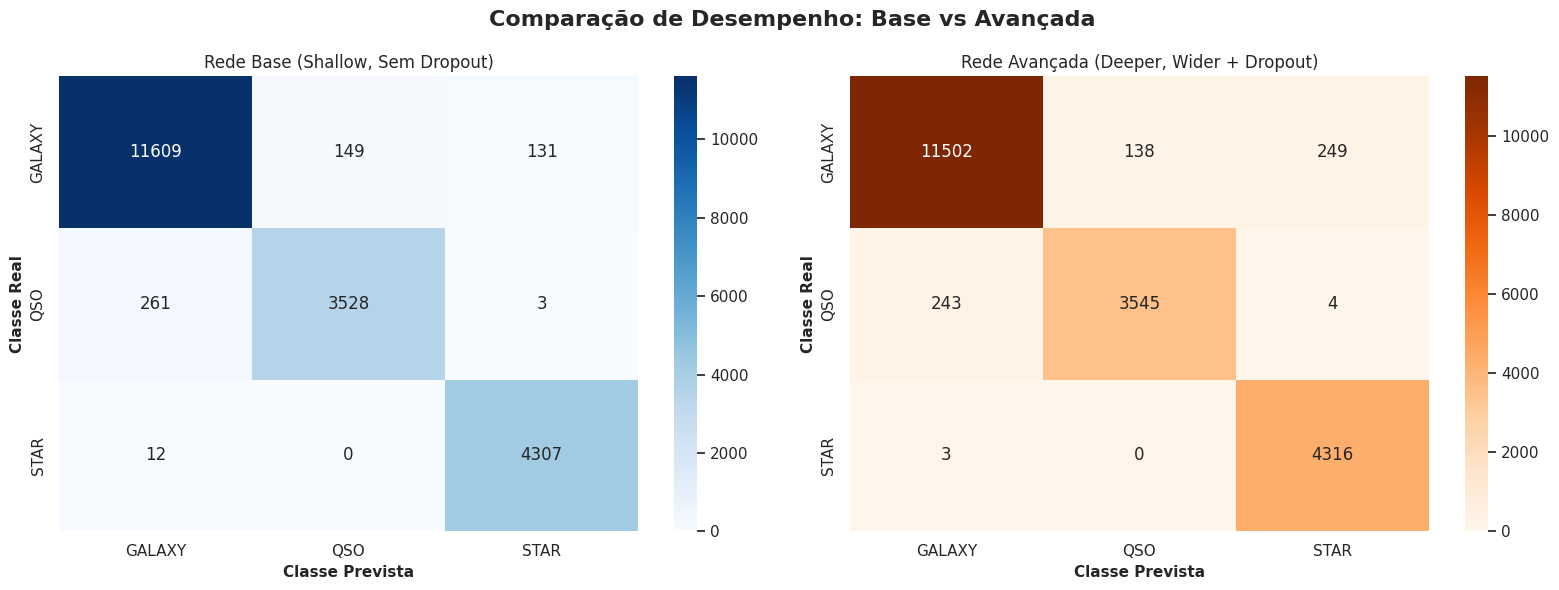

In [7]:
from sklearn.metrics import confusion_matrix

# Função auxiliar para extrair previsões
def obter_previsoes(modelo_alvo, data_loader):
    modelo_alvo.eval()
    y_real, y_pred = [], []
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            previsoes = modelo_alvo(batch_X)
            _, classe_prevista = torch.max(previsoes, 1)
            y_real.extend(batch_y.tolist())
            y_pred.extend(classe_prevista.tolist())
    return y_real, y_pred

# Coletando previsões
y_real_base, y_pred_base = obter_previsoes(modelo_base, test_loader)
y_real_adv, y_pred_adv = obter_previsoes(modelo_avancado, test_loader)

# Calculando Matrizes
cm_base = confusion_matrix(y_real_base, y_pred_base)
cm_adv = confusion_matrix(y_real_adv, y_pred_adv)

# Plotagem lado a lado
nomes_classes = encoder.classes_
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparação de Desempenho: Base vs Avançada', fontsize=16, fontweight='bold')

# Gráfico 1: Base
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=nomes_classes, yticklabels=nomes_classes)
axes[0].set_title('Rede Base (Shallow, Sem Dropout)', fontsize=12)
axes[0].set_ylabel('Classe Real', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Classe Prevista', fontsize=11, fontweight='bold')

# Gráfico 2: Avançada
sns.heatmap(cm_adv, annot=True, fmt='d', cmap='Oranges', ax=axes[1], xticklabels=nomes_classes, yticklabels=nomes_classes)
axes[1].set_title('Rede Avançada (Deeper, Wider + Dropout)', fontsize=12)
axes[1].set_ylabel('Classe Real', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Classe Prevista', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### 7. Teste de Stress: Injeção de Ruído Matemático (Simulação de Anomalia)

Para provar definitivamente que o modelo com Dropout não decorou o dataset, vamos submeter ambas as redes a um cenário de caos. Vamos pegar nos dados de teste limpos e injetar Ruído Gaussiano (simulando, por exemplo, interferência atmosférica ou uma lente suja no telescópio).

O modelo verdadeiramente robusto é aquele cuja exatidão (accuracy) sofre a menor quebra perante dados corrompidos.

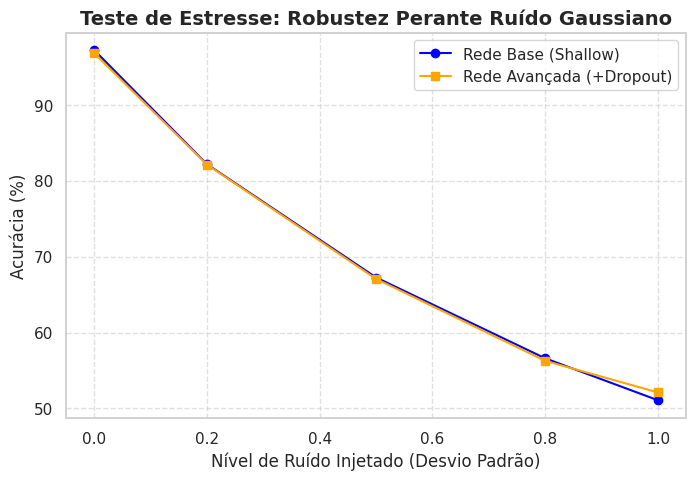

CONCLUSÃO DO TESTE DE ESTRESSE:
Queda da Rede Base (Ruído 0.0 -> 1.0): 46.13%
Queda da Rede Avançada (Ruído 0.0 -> 1.0): 44.70%


In [10]:
import torch
import numpy as np

# Função para avaliar o modelo com dados corrompidos
def avaliar_sob_estresse(modelo_alvo, X_teste, y_teste, nivel_ruido=0.5):
    modelo_alvo.eval() # Desliga o Dropout

    # Gerar ruído com a mesma forma geométrica dos dados de teste
    ruido_gaussiano = torch.randn_like(X_teste) * nivel_ruido

    # Corromper os dados (Injeção de Ruído)
    X_teste_corrompido = X_teste + ruido_gaussiano

    with torch.no_grad():
        previsoes = modelo_alvo(X_teste_corrompido)
        _, classe_prevista = torch.max(previsoes, 1)
        acertos = (classe_prevista == y_teste).sum().item()

    return (acertos / len(y_teste)) * 100

# Criando as variáveis que faltavam com base no nosso X_test do NumPy
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# Vamos testar diferentes níveis de ruído para ver quando as redes "quebram"
niveis_ruido = [0.0, 0.2, 0.5, 0.8, 1.0]
resultados_base = []
resultados_adv = []

for ruido in niveis_ruido:
    acc_base = avaliar_sob_estresse(modelo_base, X_test_tensor, y_test_tensor, ruido)
    acc_adv = avaliar_sob_estresse(modelo_avancado, X_test_tensor, y_test_tensor, ruido)

    resultados_base.append(acc_base)
    resultados_adv.append(acc_adv)

# Plotando o resultado do Teste de Estresse
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(niveis_ruido, resultados_base, marker='o', color='blue', label='Rede Base (Shallow)')
plt.plot(niveis_ruido, resultados_adv, marker='s', color='orange', label='Rede Avançada (+Dropout)')

plt.title('Teste de Estresse: Robustez Perante Ruído Gaussiano', fontsize=14, fontweight='bold')
plt.xlabel('Nível de Ruído Injetado (Desvio Padrão)', fontsize=12)
plt.ylabel('Acurácia (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("CONCLUSÃO DO TESTE DE ESTRESSE:")
print(f"Queda da Rede Base (Ruído 0.0 -> 1.0): {resultados_base[0] - resultados_base[-1]:.2f}%")
print(f"Queda da Rede Avançada (Ruído 0.0 -> 1.0): {resultados_adv[0] - resultados_adv[-1]:.2f}%")

### 8. Validação Cruzada (K-Fold Cross Validation)

Para remover qualquer dúvida de que tivemos "sorte" com a forma como o conjunto de treino/teste foi dividido no início, aplicamos o Stratified K-Fold. Vamos dividir o dataset inteiro em 5 partes (folds), treinar a rede 5 vezes do zero (uma para cada combinação de dados) e analisar a variância (Standard Deviation) da exatidão. Modelos robustos apresentam uma variância muito baixa.

In [9]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import SubsetRandomSampler

# Configurações do K-Fold
K_FOLDS = 5
kfold = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

# Converter todo o dataset normalizado (X_scaled e y_encoded) em Tensores
X_total_tensor = torch.FloatTensor(X_scaled)
y_total_tensor = torch.LongTensor(y_encoded)
dataset_total = TensorDataset(X_total_tensor, y_total_tensor)

resultados_kfold = []

print(f"Iniciando Validação Cruzada ({K_FOLDS}-Folds) na Rede Avançada...")
print("-" * 50)

# O loop K-Fold
for fold, (train_ids, test_ids) in enumerate(kfold.split(X_scaled, y_encoded)):

    # Mostradores de dados (Samplers) específicos para este Fold
    train_subsampler = SubsetRandomSampler(train_ids)
    test_subsampler = SubsetRandomSampler(test_ids)

    trainloader_fold = DataLoader(dataset_total, batch_size=64, sampler=train_subsampler)
    testloader_fold = DataLoader(dataset_total, batch_size=64, sampler=test_subsampler)

    # Criar uma rede NOVA a cada Fold para não aproveitar o treino anterior
    modelo_fold = StarClassifierAdvanced()
    criterion_fold = nn.CrossEntropyLoss()
    optimizer_fold = optim.Adam(modelo_fold.parameters(), lr=0.001)

    # Treino rápido de 15 épocas para demonstração de estabilidade
    modelo_fold.train()
    for epoch in range(15):
        for batch_X, batch_y in trainloader_fold:
            optimizer_fold.zero_grad()
            previsoes = modelo_fold(batch_X)
            loss = criterion_fold(previsoes, batch_y)
            loss.backward()
            optimizer_fold.step()

    # Avaliação do Fold
    modelo_fold.eval()
    acertos, total = 0, 0
    with torch.no_grad():
        for batch_X, batch_y in testloader_fold:
            previsoes = modelo_fold(batch_X)
            _, classe_prevista = torch.max(previsoes, 1)
            total += batch_y.size(0)
            acertos += (classe_prevista == batch_y).sum().item()

    acc_fold = (acertos / total) * 100
    resultados_kfold.append(acc_fold)
    print(f"Fold {fold+1} - Exatidão: {acc_fold:.2f}%")

print("-" * 50)
media_kfold = np.mean(resultados_kfold)
desvio_kfold = np.std(resultados_kfold)

print(f"🏁 RESULTADO FINAL K-FOLD:")
print(f"Média de Exatidão: {media_kfold:.2f}%")
print(f"Desvio Padrão (Variância): ± {desvio_kfold:.3f}%")

Iniciando Validação Cruzada (5-Folds) na Rede Avançada...
--------------------------------------------------
Fold 1 - Exatidão: 96.98%
Fold 2 - Exatidão: 97.00%
Fold 3 - Exatidão: 97.28%
Fold 4 - Exatidão: 96.97%
Fold 5 - Exatidão: 97.06%
--------------------------------------------------
🏁 RESULTADO FINAL K-FOLD:
Média de Exatidão: 97.06%
Desvio Padrão (Variância): ± 0.117%
